In [1]:
import sys
sys.path.append("..")

import torch
import numpy as np
import json
import os
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns
from torch.utils.data import DataLoader
from datasets import load_from_disk

In [ ]:
from src.data import load_model_and_tokenizer, RuleTakerDataset, PROJECT_ROOT, load_rultaker
from src.logit_lens import get_target_token_ids, compute_logit_lens, load_logit_lens_results

In [3]:
sns.set_style("whitegrid")

In [4]:
CACHE_DIR = PROJECT_ROOT / "data/processed"
RESULTS_DIR = PROJECT_ROOT / "results/logit_lens"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

# Эксперименты по анализу logit lens на Pythia-1b

## Эксперимент 4: Pythia-1b + depth-1

In [5]:
VARIANT = "depth-1"      # depth-0, depth-1, depth-2
MODEL_SIZE = "1b"        # 410m, 1b
USE_SMALL = False         # Использовать усечённую версию для отладки
BATCH_SIZE = 32

In [6]:
model, tokenizer = load_model_and_tokenizer(model_size=MODEL_SIZE, device="cuda")
model.eval()

`torch_dtype` is deprecated! Use `dtype` instead!


Loaded pretrained model EleutherAI/pythia-1b-deduped into HookedTransformer


HookedTransformer(
  (embed): Embed()
  (hook_embed): HookPoint()
  (blocks): ModuleList(
    (0-15): 16 x TransformerBlock(
      (ln1): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (ln2): LayerNorm(
        (hook_scale): HookPoint()
        (hook_normalized): HookPoint()
      )
      (attn): Attention(
        (hook_k): HookPoint()
        (hook_q): HookPoint()
        (hook_v): HookPoint()
        (hook_z): HookPoint()
        (hook_attn_scores): HookPoint()
        (hook_pattern): HookPoint()
        (hook_result): HookPoint()
        (hook_rot_k): HookPoint()
        (hook_rot_q): HookPoint()
      )
      (mlp): MLP(
        (hook_pre): HookPoint()
        (hook_post): HookPoint()
      )
      (hook_attn_in): HookPoint()
      (hook_q_input): HookPoint()
      (hook_k_input): HookPoint()
      (hook_v_input): HookPoint()
      (hook_mlp_in): HookPoint()
      (hook_attn_out): HookPoint()
      (hook_mlp_out): HookPoint()
    

In [7]:
cache_suffix = f"{VARIANT}_small" if USE_SMALL else VARIANT
cache_path = CACHE_DIR / f"ruletaker_{cache_suffix}"
dataset = load_from_disk(str(cache_path))

In [8]:
# если выборка до 5000 наблюдений
tmp_tokens = tokenizer(list(dataset["train"]["text"]), padding=False, truncation=False)
lengths = [len(ids) for ids in tmp_tokens['input_ids']]
max_full = max(lengths)
max_p95 = int(np.percentile(lengths, 95))
print(f"95-й перцентиль: {max_p95} токенов (при макс длине {max_full})")

95-й перцентиль: 199 токенов (при макс длине 273)


In [9]:
# max_p95 = estimate_max_length(list(dataset["train"]["text"]), tokenizer, percentile=95, sample_size=500)

In [10]:
MAX_LENGTH = max_p95

In [11]:
train_dataset = RuleTakerDataset(dataset["train"], tokenizer, max_length=MAX_LENGTH)
dev_dataset = RuleTakerDataset(dataset["dev"], tokenizer, max_length=MAX_LENGTH)

In [12]:
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
dev_loader   = DataLoader(dev_dataset, batch_size=BATCH_SIZE, shuffle=False)

In [13]:
torch.cuda.empty_cache()

In [14]:
TRUE_TOKEN_IDS, FALSE_TOKEN_IDS = get_target_token_ids(tokenizer)

In [15]:
# logit lens
results = compute_logit_lens(
    model,
    dev_loader,
    model.cfg.n_layers,
    TRUE_TOKEN_IDS,
    FALSE_TOKEN_IDS,
    device="cuda"
)

In [16]:
dev_accs = results["accs"]
dev_prob_true = results["mean_prob_true"]
dev_prob_false = results["mean_prob_false"]

In [17]:
best_layer = int(np.argmax(dev_accs))
best_acc = float(dev_accs[best_layer])
print(f"Лучший слой: {best_layer}, Accuracy: {best_acc:.4f}")

Лучший слой: 3, Accuracy: 0.5023


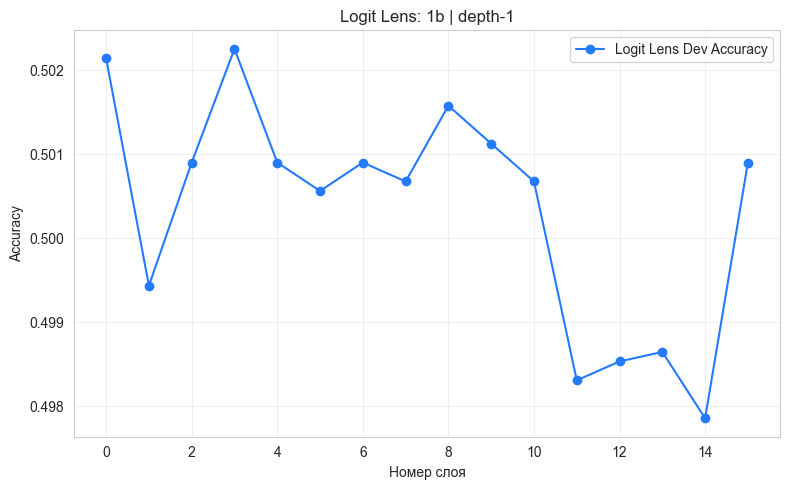

In [18]:
plt.figure(figsize=(8, 5))
x = np.arange(model.cfg.n_layers)
plt.plot(x, dev_accs, marker="o", label="Logit Lens Dev Accuracy", color="xkcd:clear blue")
# plt.axhline(0.5, color="gray", linestyle="--", alpha=0.6, label="Random baseline")
# plt.axvline(best_layer, color="r", linestyle=":", alpha=0.5, label=f"Best layer ({best_layer})")
plt.xlabel("Номер слоя")
plt.ylabel("Accuracy")
plt.title(f"Logit Lens: {MODEL_SIZE} | {VARIANT}")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [21]:
results

{'accs': array([0.50214205, 0.4994363 , 0.50090192, 0.50225479, 0.50090192,
        0.5005637 , 0.50090192, 0.50067644, 0.50157835, 0.5011274 ,
        0.50067644, 0.49830891, 0.49853439, 0.49864713, 0.49785795,
        0.50090192]),
 'mean_prob_true': array([2.52475872e-05, 4.31969612e-06, 1.56932872e-05, 9.14155331e-05,
        5.36673011e-05, 6.56472441e-05, 6.58044547e-05, 8.26054003e-05,
        6.53658700e-05, 9.64578589e-05, 2.04465244e-04, 6.87583904e-05,
        1.36782516e-04, 2.66918004e-04, 2.36209150e-04, 1.01956999e-04]),
 'mean_prob_false': array([3.29882687e-06, 5.02149253e-06, 1.76577967e-05, 2.84878184e-05,
        3.37912198e-05, 2.96294165e-05, 3.25940066e-05, 3.43332230e-05,
        2.91014882e-05, 6.63569985e-05, 1.28613661e-04, 2.13516048e-04,
        4.97647090e-04, 6.27893734e-04, 2.31100177e-04, 7.58728704e-05]),
 'mean_abs_diff': array([2.21076781e-05, 1.76576463e-06, 2.73083344e-06, 6.38927536e-05,
        2.23789021e-05, 4.16931552e-05, 3.95694521e-05, 5.29

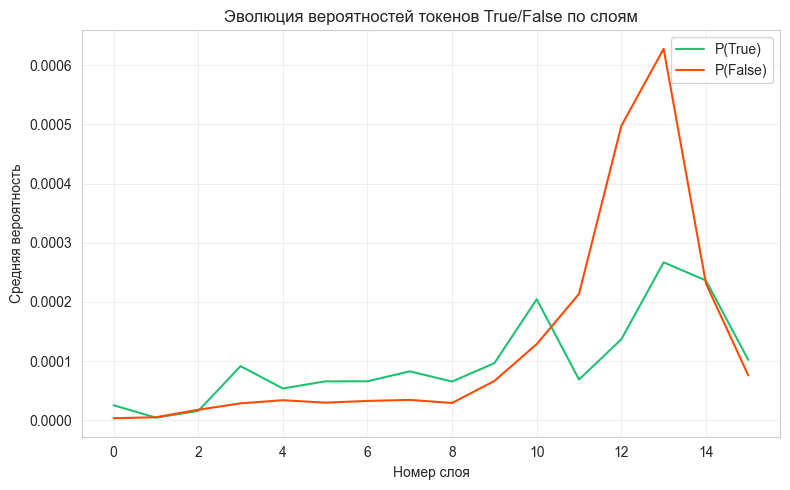

In [19]:
plt.figure(figsize=(8, 5))
plt.plot(x, dev_prob_true, label="P(True)", color="xkcd:dark mint green")
plt.plot(x, dev_prob_false, label="P(False)", color="xkcd:blood orange")
# plt.axvline(best_layer, color="k", linestyle="--", alpha=0.4)
plt.xlabel("Номер слоя")
plt.ylabel("Средняя вероятность")
plt.title("Эволюция вероятностей токенов True/False по слоям")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [20]:
# Сохранение метрик в JSON
fname = f"logit_lens_{MODEL_SIZE}_{VARIANT}.json"
fpath = RESULTS_DIR / fname

metrics = {
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "best_layer": best_layer,
    "best_dev_acc": float(best_acc),
    "accs": [float(x) for x in results["accs"]],
    "mean_prob_true": [float(x) for x in results["mean_prob_true"]],
    "mean_prob_false": [float(x) for x in results["mean_prob_false"]],
    "mean_abs_diff": [float(x) for x in results["mean_abs_diff"]],
    "mean_confidence": [float(x) for x in results["mean_confidence"]],
    "mean_entropy": [float(x) for x in results["mean_entropy"]],
    "mean_agreement": [float(x) for x in results["mean_agreement"]]
}

# Исходные условия эксперимента
metadata = {
    "experiment_type": "logit_lens_analysis",
    "timestamp": datetime.now().isoformat(),
    "variant": VARIANT,
    "model_size": MODEL_SIZE,
    "batch_size": BATCH_SIZE,
    "max_length": MAX_LENGTH
}

# Основной результат
summary = {
    "best_layer": best_layer,
    "best_dev_acc": float(best_acc),
    "n_layers": len(results["accs"])
}

# Свод
full_data = {
    "metadata": metadata,
    "summary": summary,
    "layers": list(range(len(results["accs"]))),
    "accs": [float(x) for x in results["accs"]],
    "mean_prob_true": [float(x) for x in results["mean_prob_true"]],
    "mean_prob_false": [float(x) for x in results["mean_prob_false"]],
    "mean_abs_diff": [float(x) for x in results["mean_abs_diff"]],
    "mean_confidence": [float(x) for x in results["mean_confidence"]],
    "mean_entropy": [float(x) for x in results["mean_entropy"]],
    "mean_agreement": [float(x) for x in results["mean_agreement"]]
}

with open(fpath, "w", encoding="utf-8") as f:
    json.dump(full_data, f, indent=2, ensure_ascii=False)
print(f"Результаты сохранены: {fpath}")

Результаты сохранены: C:\MyPythonProjects\mephi_diss\results\logit_lens\logit_lens_1b_depth-1.json
